## Set Up Environment

#### Install and Import Necessary Libraries

In [144]:
# install xgboost
!pip install xgboost


In [145]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from scipy.stats import linregress
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

#### Read consolidated, cleaned, and pre-processed data stored in `.\Milestone 3` directory

In [225]:
birdsong_df = pd.read_csv("..\\birdsong_df.csv")
#  validate that the data was loaded correctly by checking the first few rows and the data types of each column.
print("Original DataFrame:")
print(birdsong_df.head())
print(birdsong_df.info())

Original DataFrame:
             common_name     date  bird_count    county  \
0         Cackling Goose  2021-01        30.0  Arapahoe   
1           Canada Goose  2021-01       100.0  Arapahoe   
2       Great Horned Owl  2021-01         1.0  Arapahoe   
3    Eastern Screech-Owl  2021-01         2.0   Larimer   
4  Northern Saw-whet Owl  2021-01         1.0   Larimer   

                        family  total_monthly_precipitation  monthly_max_temp  \
0  Ducks, Geese, and Waterfowl                     6.388095          7.923333   
1  Ducks, Geese, and Waterfowl                     6.388095          7.923333   
2                         Owls                     6.388095          7.923333   
3                         Owls                    10.825893          1.854118   
4                         Owls                    10.825893          1.854118   

   monthly_min_temp  urban_population_level  county_total_population  is_fire  \
0         -5.823333                       5              

## Additional Data Transformations for Random Forest Model 

#### Group Data by Family and Month to Calculate Population Trend

In [226]:
# save date as year in new column called year
birdsong_df['month-year'] = pd.to_datetime(birdsong_df['date']).dt.to_period('M')
# aggregate data by family, and year to get total bird count, family total population and average min and max temperatures per family, per month-year combination
birdsong_df_family_month = birdsong_df.groupby(['family', 'month-year', 'season','county']).agg({'bird_count': 'sum',
'county_total_population': 'mean', 'monthly_min_temp': 'mean', 'monthly_max_temp': 'mean', 'total_monthly_precipitation': 
'mean', 'bird_count_adjusted_for_population': 'sum','is_fire': 'max', 'is_flood': 'max','urban_population_level': 
'max'}).reset_index()
birdsong_df_family_month.head(20)
birdsong_df_family_month.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59274 entries, 0 to 59273
Data columns (total 13 columns):
 #   Column                              Non-Null Count  Dtype    
---  ------                              --------------  -----    
 0   family                              59274 non-null  object   
 1   month-year                          59274 non-null  period[M]
 2   season                              59274 non-null  object   
 3   county                              59274 non-null  object   
 4   bird_count                          59274 non-null  float64  
 5   county_total_population             59274 non-null  float64  
 6   monthly_min_temp                    59274 non-null  float64  
 7   monthly_max_temp                    59274 non-null  float64  
 8   total_monthly_precipitation         59274 non-null  float64  
 9   bird_count_adjusted_for_population  59274 non-null  float64  
 10  is_fire                             59274 non-null  int64    
 11  is_flood       

#### Calculate Population Trend for each Family

In [230]:
# calculate slope of bird_count per family over entire timeframe and include the slope as a new column in the original DataFrame
slopes = birdsong_df_family_month.groupby('family')['bird_count'].apply(lambda x: linregress(range(len(x)), x).slope)
# add slopes to original dataframe
birdsong_df_month = birdsong_df.merge(slopes.rename('trend_slope'), on='family')
print(birdsong_df_month.head(20))

                 common_name     date  bird_count    county  \
0             Cackling Goose  2021-01        30.0  Arapahoe   
1               Canada Goose  2021-01       100.0  Arapahoe   
2           Great Horned Owl  2021-01         1.0  Arapahoe   
3        Eastern Screech-Owl  2021-01         2.0   Larimer   
4      Northern Saw-whet Owl  2021-01         1.0   Larimer   
5         Northern Pygmy-Owl  2021-01         1.0   Larimer   
6                 Bald Eagle  2021-01         2.0  Arapahoe   
7              Cooper's Hawk  2021-01         1.0  Arapahoe   
8           Downy Woodpecker  2021-01         1.0  Arapahoe   
9       Red-winged Blackbird  2021-01       150.0  Arapahoe   
10              Song Sparrow  2021-01         5.0  Arapahoe   
11                   Mallard  2021-01         1.0    Pueblo   
12               Rock Pigeon  2021-01         1.0    Pueblo   
13             American Crow  2021-01         2.0   El Paso   
14     American Herring Gull  2021-01       200.0   Lar

c:\Users\melis\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:10730: RuntimeWarning: invalid value encountered in scalar divide
  slope = ssxym / ssxm
c:\Users\melis\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:10744: RuntimeWarning: invalid value encountered in sqrt
  t = r * np.sqrt(df / ((1.0 - r + TINY)*(1.0 + r + TINY)))
c:\Users\melis\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:10750: RuntimeWarning: invalid value encountered in scalar divide
  slope_stderr = np.sqrt((1 - r**2) * ssym / ssxm / df)


#### Convert Season to Binary Variables Using One Hot Encoding

In [228]:
# create dummy variables for season and concatenate them with the original dataframe, then drop the original season column
season_dummies = pd.get_dummies(birdsong_df_month['season'], prefix='season', dtype=int)
birdsong_df_month = pd.concat([birdsong_df_month, season_dummies], axis=1)
birdsong_df_month.drop('season', axis=1, inplace=True)

print("Transformed DataFrame:")
birdsong_df_month.head()
# birdsong_df.info()

Transformed DataFrame:


,common_name,date,bird_count,county,family,total_monthly_precipitation,monthly_max_temp,monthly_min_temp,urban_population_level,county_total_population,is_fire,is_flood,bird_count_adjusted_for_population,month-year,trend_slope,season_Autumn,season_Spring,season_Summer,season_Winter
0,Cackling Goose,2021-01,30.0,Arapahoe,"Ducks, Geese, and Waterfowl",6.388095,7.923333,-5.823333,5,660310.560,0,0,0.000045,2021-01,-0.091052,0,0,0,1
1,Canada Goose,2021-01,100.0,Arapahoe,"Ducks, Geese, and Waterfowl",6.388095,7.923333,-5.823333,5,660310.560,0,0,0.000151,2021-01,-0.091052,0,0,0,1
2,Great Horned Owl,2021-01,1.0,Arapahoe,Owls,6.388095,7.923333,-5.823333,5,660310.560,0,0,0.000002,2021-01,0.000221,0,0,0,1
3,Eastern Screech-Owl,2021-01,2.0,Larimer,Owls,10.825893,1.854118,-10.457222,5,361938.528,0,0,0.000006,2021-01,0.000221,0,0,0,1
4,Northern Saw-whet Owl,2021-01,1.0,Larimer,Owls,10.825893,1.854118,-10.457222,5,361938.528,0,0,0.000003,2021-01,0.000221,0,0,0,1


#### Add Binary Variable to Indicate Declining Population

In [229]:
# add binary target variable called is_declining to indicate whether bird count is trending downward (slope < 0) or not (slope >= 0)
birdsong_df_month['is_declining'] = (birdsong_df_month['trend_slope'] < 0).astype(int)
print(birdsong_df_month[['family', 'trend_slope', 'is_declining']].drop_duplicates())

                               family  trend_slope  is_declining
0         Ducks, Geese, and Waterfowl    -0.091052             1
2                                Owls     0.000221             0
6            Hawks, Eagles, and Kites    -0.000443             1
8                         Woodpeckers     0.000203             0
9                Troupials and Allies    -0.005899             1
...                               ...          ...           ...
174703                        Limpkin    -2.000000             1
243592  New World and African Parrots          NaN             0
308783            Boobies and Gannets          NaN             0
316419            Cassowaries and Emu          NaN             0
322794                         Storks     0.000000             0

[65 rows x 3 columns]


## Implement Model

#### Load dataset

In [204]:
# create copy of dataframe for modeling
birds = birdsong_df_month

# define features and target variable
features = [
    # 'bird_count', don't include this because it is a direct measure of the target variable
    'total_monthly_precipitation',
    'monthly_max_temp',
    # 'monthly_min_temp', don't include this because it's highly correlated with max temp
    'county_total_population',
    'is_fire',
    'is_flood',
    'season_Winter', 
    'season_Spring', 
    'season_Summer', 
    'season_Autumn'
]

X = birds[features]
y = birds['is_declining']

##### Define Training and Test Datasets

In [205]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Train Random Forest Classifier

In [206]:
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', random_state=42)

#### Evaluate Model and Print Reports

              precision    recall  f1-score   support

           0       0.41      0.50      0.45     24267
           1       0.70      0.61      0.65     45409

    accuracy                           0.57     69676
   macro avg       0.55      0.56      0.55     69676
weighted avg       0.60      0.57      0.58     69676



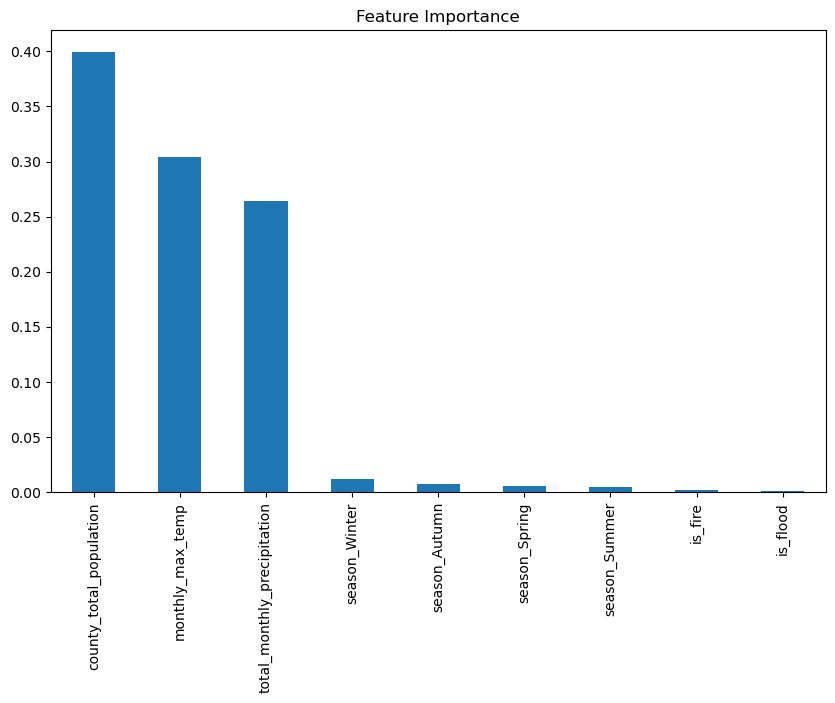

In [207]:
# print classification report
print(classification_report(y_test, model.predict(X_test)))


# print feature importances
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
importances.plot(kind='bar')
plt.title('Feature Importance')
plt.show()

## Refine Model Based on Feature Importance and Predictions

#### Load dataset

In [211]:
# create copy of dataframe for modeling
birds = birdsong_df_month

# define features and target variable
features = [
    # 'bird_count', don't include this because it is a direct measure of the target variable
    'total_monthly_precipitation',
    'monthly_max_temp',
    # 'monthly_min_temp', don't include this because it's highly correlated with max temp
    'county_total_population'
    # don't include these because they are not very important to the model:
    # 'is_fire',
    # 'is_flood',
    # 'season_Winter', 
    # 'season_Spring', 
    # 'season_Summer', 
    # 'season_Autumn'
]

X = birds[features]
y = birds['is_declining']

##### Define Training and Test Datasets

In [212]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Train Random Forest Classifier

In [213]:
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', random_state=42)

#### Evaluate Model and Print Reports

              precision    recall  f1-score   support

           0       0.41      0.50      0.45     24267
           1       0.70      0.61      0.65     45409

    accuracy                           0.57     69676
   macro avg       0.55      0.56      0.55     69676
weighted avg       0.60      0.57      0.58     69676



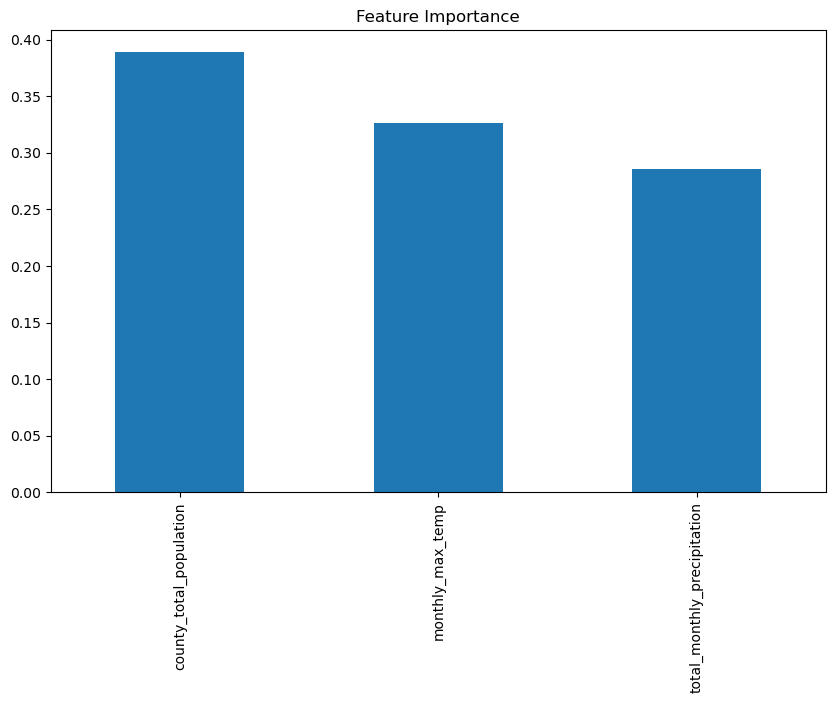

In [214]:
# print classification report
print(classification_report(y_test, model.predict(X_test)))


# print feature importances
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
importances.plot(kind='bar')
plt.title('Feature Importance')
plt.show()

## Try Stronger Test (XGBoost instead of Random Forest)

#### Load Dataset

In [215]:
# create copy of dataframe for modeling
birds = birdsong_df_month

# define features and target variable
features = [
    # 'bird_count',
    'total_monthly_precipitation',
    'monthly_max_temp',
    # 'monthly_min_temp', don't include this because it's highly correlated with max temp
    'county_total_population'
    # don't include these because they are not very important to the model:
    # 'is_fire',
    # 'is_flood',
    # 'season_Winter', 
    # 'season_Spring', 
    # 'season_Summer', 
    # 'season_Autumn'
]

X = birds[features]
y = birds['is_declining']

##### Define Training and Test Datasets

In [216]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Tune Hyperparameter

In [217]:
model = XGBClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'scale_pos_weight': [len(y_train[y_train==0])/len(y_train[y_train==1])]
}

grid = GridSearchCV(model, param_grid, scoring='f1', cv=5, verbose=1, n_jobs=-1)
grid.fit(X_train, y_train)

# See best params and score
print("Best params:", grid.best_params_)
print("Best F1:", grid.best_score_)

# Use best model to predict
y_pred = grid.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'scale_pos_weight': 0.5342155821135437, 'subsample': 0.7}
Best F1: 0.6511966745433521
              precision    recall  f1-score   support

           0       0.41      0.50      0.45     24267
           1       0.69      0.61      0.65     45409

    accuracy                           0.57     69676
   macro avg       0.55      0.55      0.55     69676
weighted avg       0.59      0.57      0.58     69676



#### Train XG Boost Classifier

In [218]:
model = XGBClassifier(**grid.best_params_)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

#### Evaluate Model and Print Reports

              precision    recall  f1-score   support

           0       0.40      0.50      0.45     24267
           1       0.69      0.60      0.65     45409

    accuracy                           0.57     69676
   macro avg       0.55      0.55      0.55     69676
weighted avg       0.59      0.57      0.58     69676



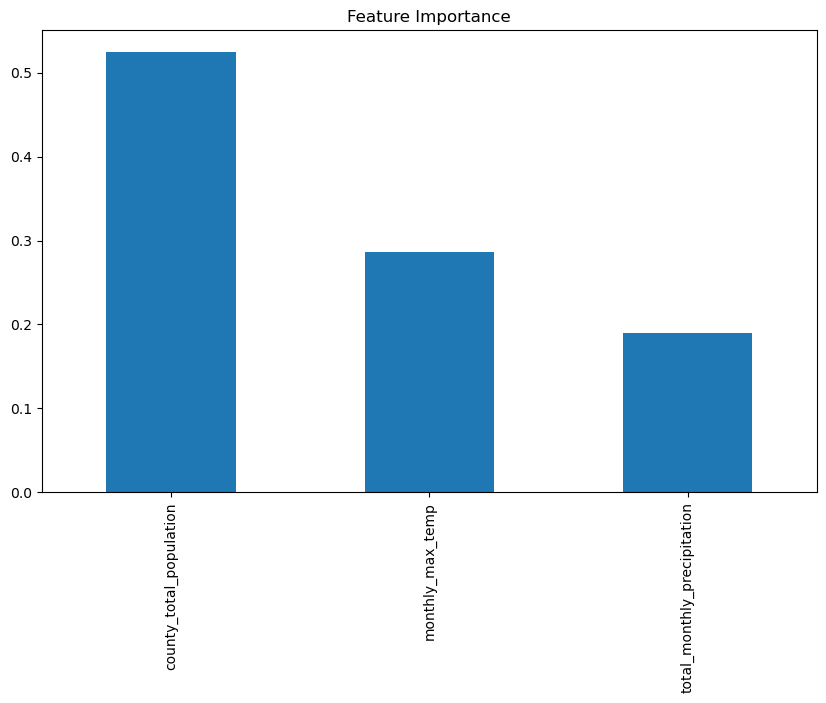

In [219]:
# print classification report
print(classification_report(y_test, model.predict(X_test)))


# print feature importances
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
importances.plot(kind='bar')
plt.title('Feature Importance')
plt.show()

#### Print Predictions for Each Family

In [ ]:
# generate predictions
test_results = X_test.copy()
test_results['true_label'] = y_test
test_results['predicted_label'] = model.predict(X_test)

# merge test results with family and trend_slope data from birdsong_df_month
test_results = test_results.merge(birdsong_df_month[['family', 'trend_slope']], left_index=True, right_index=True)

# sort test results by trend_slope to identify families most at risk of extinction (most negative slopes) and see how the model is performing on those families
test_results = test_results.sort_values('trend_slope')
print(test_results[['family', 'trend_slope', 'true_label', 'predicted_label']].groupby('family').first().sort_values('trend_slope').head(20))

                                trend_slope  true_label  predicted_label
family                                                                  
Guineafowl                        -0.155172           1                1
Cranes                            -0.118024           1                0
Pelicans                          -0.116880           1                1
Ducks, Geese, and Waterfowl       -0.091052           1                1
Gulls, Terns, and Skimmers        -0.055325           1                1
Skuas and Jaegers                 -0.051304           1                1
Waxwings                          -0.028535           1                0
Stilts and Avocets                -0.007796           1                1
Herons, Egrets, and Bitterns      -0.007170           1                1
Finches, Euphonias, and Allies    -0.007101           1                1
Yellow-breasted Chat              -0.007048           1                1
Troupials and Allies              -0.005899        